# ML Classification Model for Iris Dataset

In [65]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.metrics import classification_report

In [17]:
df = pd.read_csv("./data/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [23]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [38]:
# I'll start by checking the number of examples of each specicies. 
df["Species"].value_counts() #Iris is perfectly balanced w/ each species having 50 entries

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

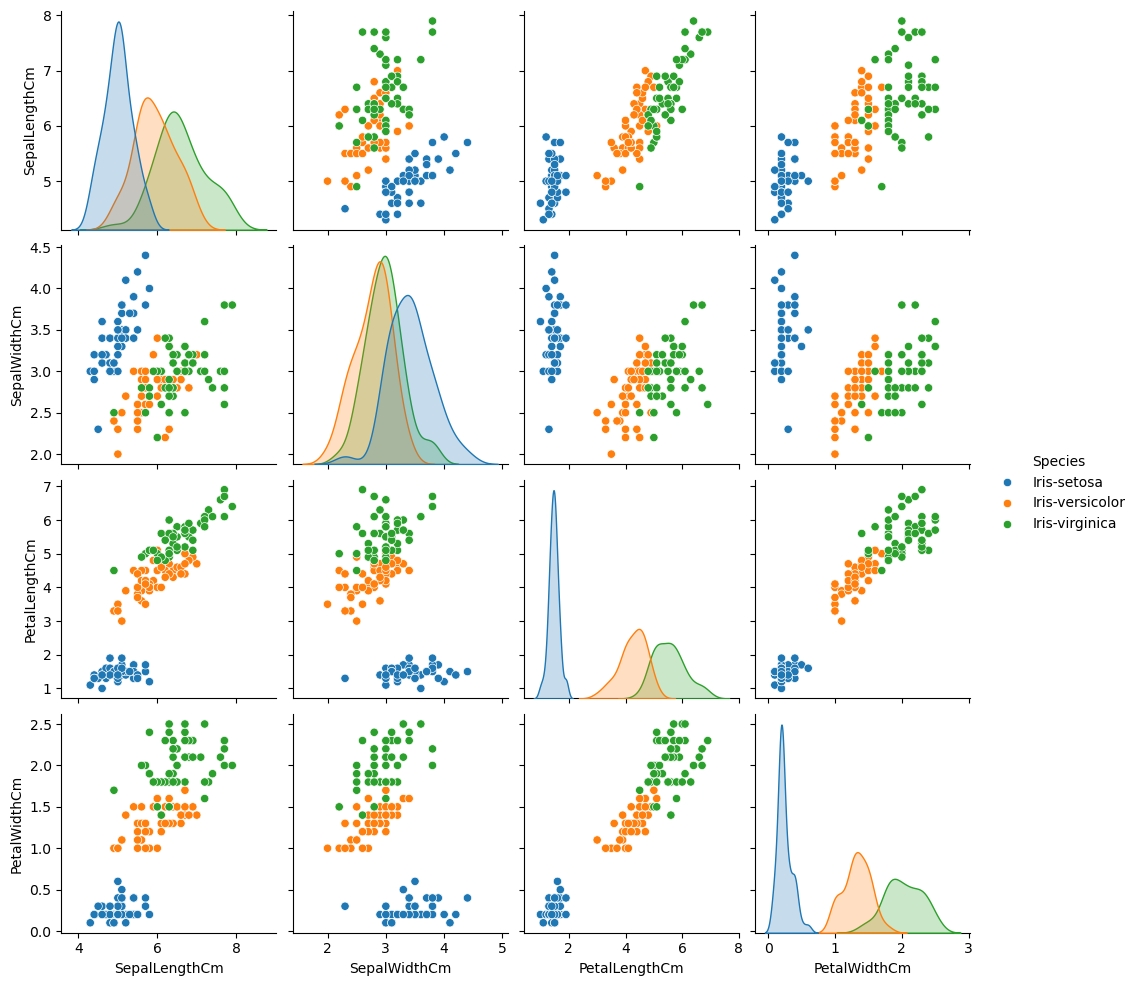

In [49]:
sns.pairplot(df, hue="Species") #Iris-setosa is very seperable from the rest, virginica and versicolor have some overlap
#Petal length vs petal width seperate the classes pretty well
#Sepal length and sepel width do a poor job seperating classes

From the pairplot, petal length and petal width show very strong separation between the classes, especially with Iris-setosa being clearly distinct from the other two species. In contrast, sepal length and sepal width show significant overlap between Iris-versicolor and Iris-virginica, making them less useful for classification. This suggests that petal-based features will likely be more important for model performance.

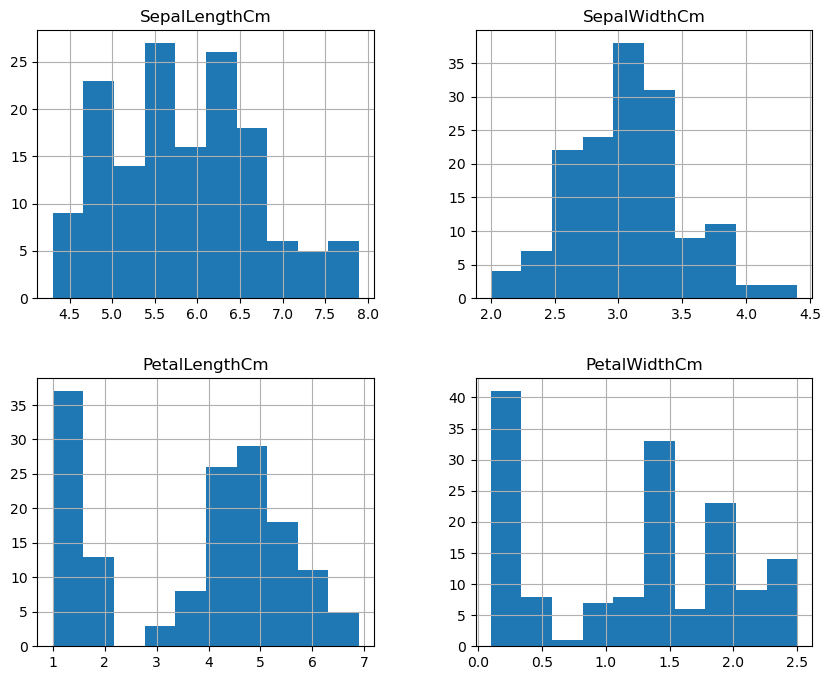

In [50]:
df.hist(figsize=(10,8))
plt.show()

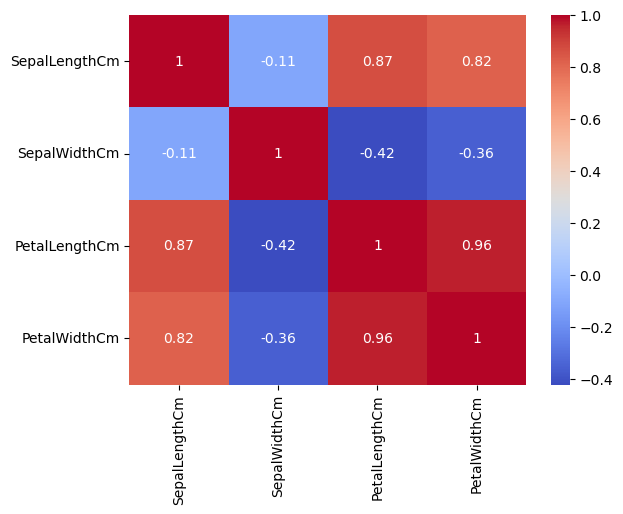

In [57]:
sns.heatmap(df.drop("Species", axis=1).corr(), annot=True, cmap="coolwarm")
plt.show()

The correlation heatmap shows strong positive relationships between petal length and petal width (0.96), as well as moderate to strong correlations between sepal length and the petal features. This suggests that larger flowers tend to have larger measurements across multiple features. However, despite these correlations, earlier visualizations indicate that petal based features provide better class separation than sepal-based features.

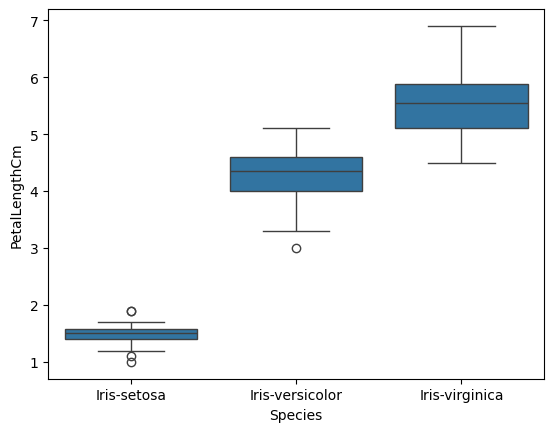

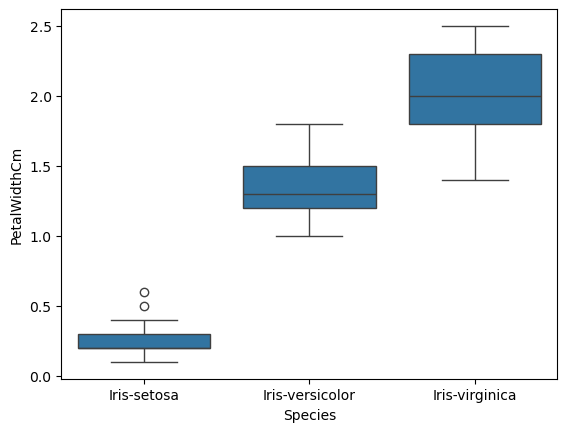

In [56]:
#Now I will compare the petal width,length vs the target feature Species
sns.boxplot(x="Species", y="PetalLengthCm", data=df)
plt.show()
sns.boxplot(x="Species", y="PetalWidthCm", data=df)
plt.show()

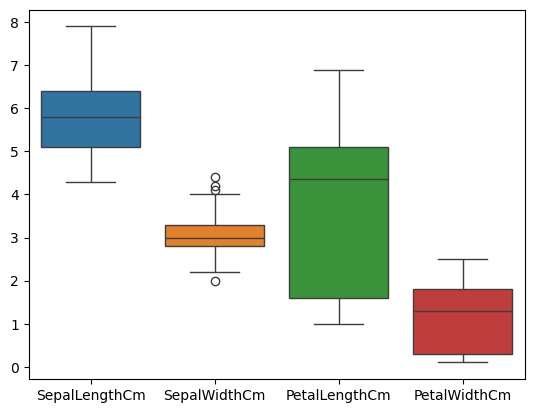

In [53]:
sns.boxplot(data=df.drop(["Species"], axis=1))
plt.show()
#No major outliers 

In [63]:
X = df.drop(["Species"], axis=1)
y = df["Species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #80/20 split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "RF": RandomForestClassifier(random_state=42)
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_results[name] = scores
    print(name, scores.mean(), scores.std())

LogReg 0.9583333333333334 0.045643546458763846
KNN 0.9333333333333333 0.0565194165260439
SVM 0.95 0.06123724356957944
RF 0.95 0.04082482904638631


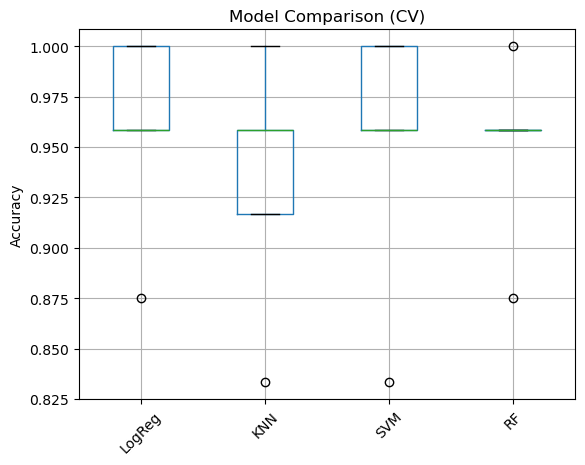

In [67]:
pd.DataFrame(cv_results).boxplot()
plt.title("Model Comparison (CV)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

In [39]:
#Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [40]:
#Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [41]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [48]:
#Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

